In [99]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime as dt
import math

from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [100]:
df = pd.read_csv('Impute_misvalues_hungyen.csv')
df.head()

,Date,Hour,Waterlevel
0,1/1/2008,0,47.0
1,1/1/2008,1,43.0
2,1/1/2008,2,40.0
3,1/1/2008,3,37.0
4,1/1/2008,4,34.0


In [101]:
df['Hour'] = df['Hour'].replace('#NUM!', 0)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64061 entries, 0 to 64060
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        64061 non-null  object 
 1   Hour        64061 non-null  object 
 2   Waterlevel  64061 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.5+ MB


In [103]:
df.isnull().sum()

Date          0
Hour          0
Waterlevel    0
dtype: int64

In [104]:
# df.loc[df['Hour'] == 'NUM!', 'Hour'] = 0
df['Hour'] = pd.to_datetime(df['Hour'], format='%H', errors='coerce').dt.time
df.head()

,Date,Hour,Waterlevel
0,1/1/2008,00:00:00,47.0
1,1/1/2008,01:00:00,43.0
2,1/1/2008,02:00:00,40.0
3,1/1/2008,03:00:00,37.0
4,1/1/2008,04:00:00,34.0


In [105]:
df['Hour'] = df['Hour'].astype(str)


df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Hour'])
df = df.set_index('DateTime')
df.drop(['Date', 'Hour'], axis = 1, inplace = True)

df.head()

,Waterlevel
DateTime,
2008-01-01 00:00:00,47.0
2008-01-01 01:00:00,43.0
2008-01-01 02:00:00,40.0
2008-01-01 03:00:00,37.0
2008-01-01 04:00:00,34.0


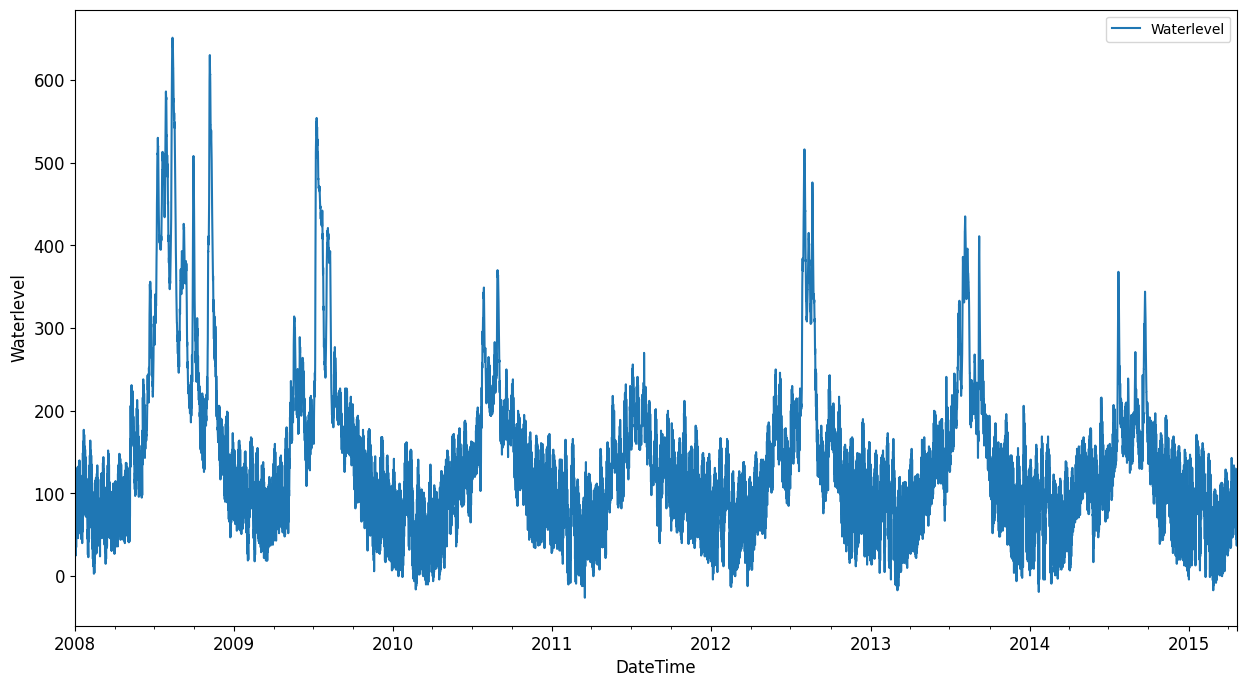

In [106]:
df.plot(y='Waterlevel', subplots=True, figsize=(15, 8), fontsize=12)
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Waterlevel', fontsize=12)
plt.show()

In [107]:
train_size = int(len(df) * 0.7)
train, test = df[:train_size].iloc[:, [-1]], df[train_size:].iloc[:, [-1]]

train, test

(                     Waterlevel
 DateTime                       
 2008-01-01 00:00:00        47.0
 2008-01-01 01:00:00        43.0
 2008-01-01 02:00:00        40.0
 2008-01-01 03:00:00        37.0
 2008-01-01 04:00:00        34.0
 ...                         ...
 2013-02-11 05:00:00        86.0
 2013-02-11 06:00:00       100.0
 2013-02-11 07:00:00       115.0
 2013-02-11 08:00:00       128.0
 2013-02-11 09:00:00       134.0
 
 [44842 rows x 1 columns],
                      Waterlevel
 DateTime                       
 2013-02-11 10:00:00       133.0
 2013-02-11 11:00:00       127.0
 2013-02-11 12:00:00       122.0
 2013-02-11 13:00:00       115.0
 2013-02-11 14:00:00       107.0
 ...                         ...
 2015-04-23 00:00:00       127.0
 2015-04-23 01:00:00       124.0
 2015-04-23 02:00:00       120.0
 2015-04-23 03:00:00       115.0
 2015-04-23 04:00:00       109.0
 
 [19219 rows x 1 columns])

In [108]:
train.shape, test.shape

((44842, 1), (19219, 1))

Text(0, 0.5, 'Waterlevel')

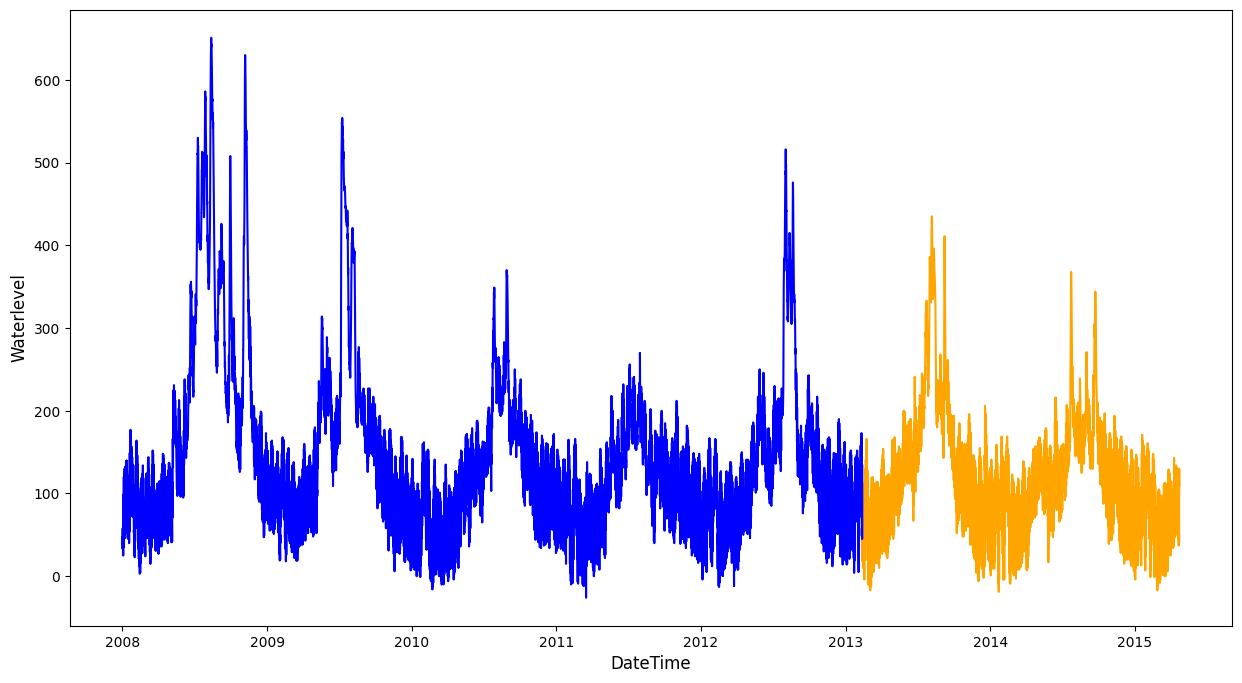

In [109]:
plt.figure(figsize = (15,8))
plt.plot(test.index, test['Waterlevel'], label = "test", color = 'orange')
plt.plot(train.index, train['Waterlevel'], label = "train" , color = 'blue')
plt.xlabel('DateTime', fontsize=12)
plt.ylabel('Waterlevel', fontsize=12)

In [110]:
scaler = MinMaxScaler()
train['Waterlevel'] = scaler.fit_transform(train)

In [111]:
test['Waterlevel'] = scaler.transform(test)

In [112]:
# Converting to numpy arrays
train_data = train.values
test_data = test.values

In [113]:
timesteps=5

In [114]:
train_data_timesteps=np.array([[j for j in train_data[i:i+timesteps]] for i in range(0,len(train_data)-timesteps+1)])[:,:,0]
train_data_timesteps.shape

(44838, 5)

In [115]:
test_data_timesteps=np.array([[j for j in test_data[i:i+timesteps]] for i in range(0,len(test_data)-timesteps+1)])[:,:,0]
test_data_timesteps.shape

(19215, 5)

In [116]:
x_train, y_train = train_data_timesteps[:,:timesteps-1],train_data_timesteps[:,[timesteps-1]]
x_test, y_test = test_data_timesteps[:,:timesteps-1],test_data_timesteps[:,[timesteps-1]]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(44838, 4) (44838, 1)
(19215, 4) (19215, 1)


In [117]:
model = SVR(kernel='rbf',gamma=0.5, C=10, epsilon = 0.05)

In [118]:
model.fit(x_train, y_train[:,0])

SVR(C=10, epsilon=0.05, gamma=0.5)

In [119]:
y_train_pred = model.predict(x_train).reshape(-1,1)
y_test_pred = model.predict(x_test).reshape(-1,1)

print(y_train_pred.shape, y_test_pred.shape)

(44838, 1) (19215, 1)


In [120]:
# Scaling the predictions
y_train_pred = scaler.inverse_transform(y_train_pred)
y_test_pred = scaler.inverse_transform(y_test_pred)

print(len(y_train_pred), len(y_test_pred))

44838 19215


In [121]:
# Scaling the original values
y_train = scaler.inverse_transform(y_train)
y_test = scaler.inverse_transform(y_test)

print(len(y_train), len(y_test))

44838 19215


In [122]:
train_timestamps = train.index[timesteps-1:]
test_timestamps = test.index[timesteps-1:]

print(len(train_timestamps), len(test_timestamps))

44838 19215


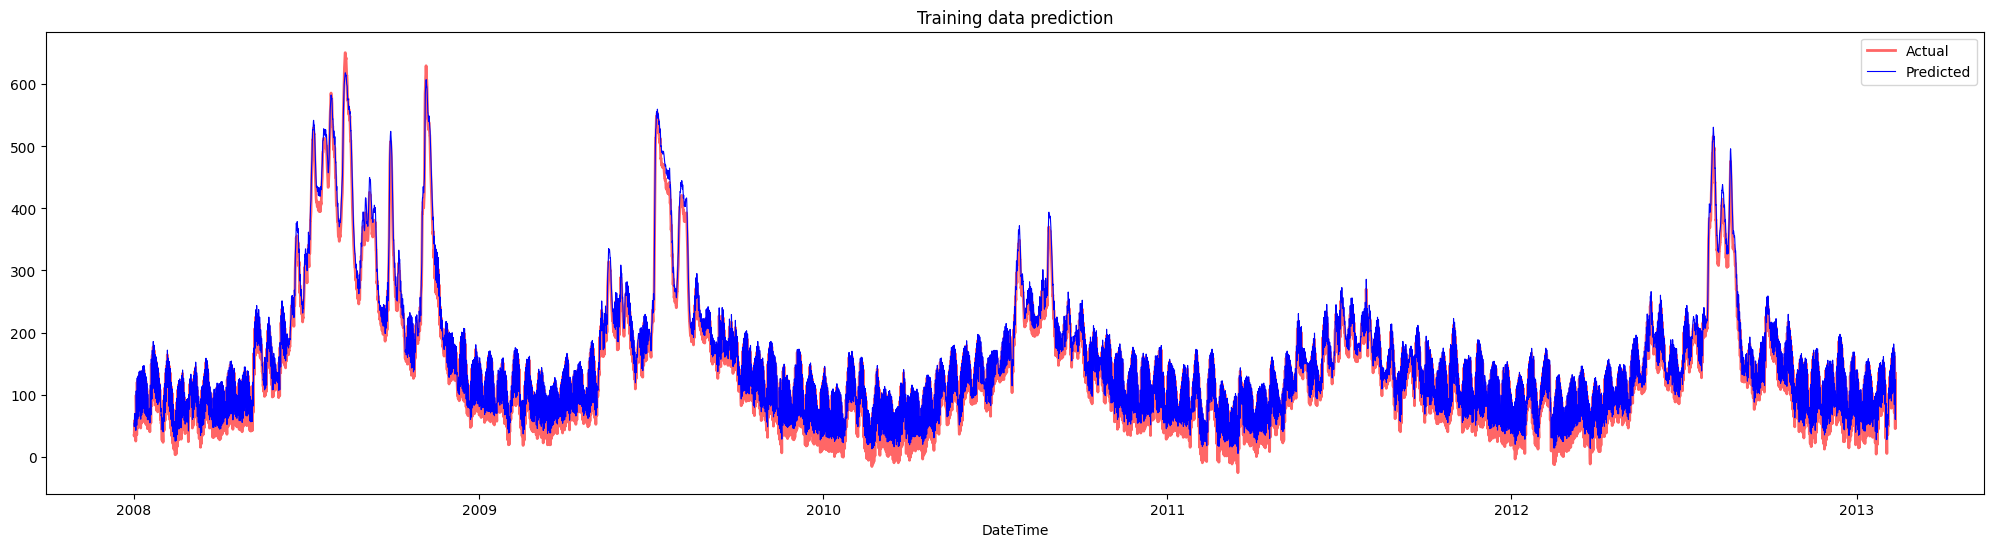

In [123]:
plt.figure(figsize=(25,6))
plt.plot(train_timestamps, y_train, color = 'red', linewidth=2.0, alpha = 0.6)
plt.plot(train_timestamps, y_train_pred, color = 'blue', linewidth=0.8)
plt.legend(['Actual','Predicted'])
plt.xlabel('DateTime')
plt.title("Training data prediction")
plt.show()

In [124]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_train, y_train_pred)
print('MAPE for training data: ', mape*100, '%')

MAPE for training data:  3510046411239704.5 %


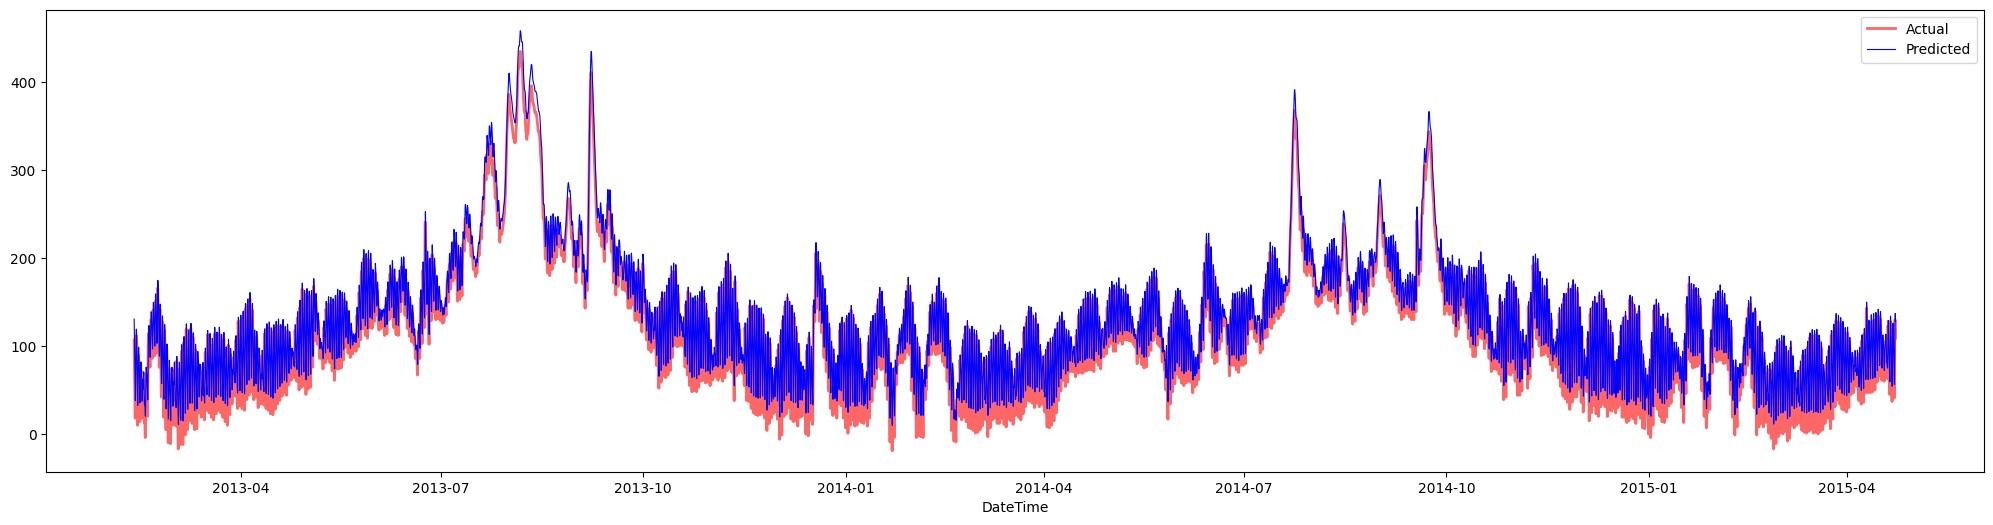

In [125]:
plt.figure(figsize=(25,6))
plt.plot(test_timestamps, y_test, color = 'red', linewidth=2.0, alpha = 0.6)
plt.plot(test_timestamps, y_test_pred, color = 'blue', linewidth=0.8)
plt.legend(['Actual','Predicted'])
plt.xlabel('DateTime')
plt.show()

In [126]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, y_test_pred)
print('MAPE for training data: ', mape*100, '%')

MAPE for training data:  6294808871773111.0 %


In [127]:
y_test_flat = y_test.flatten()
y_test_pred_flat = y_test_pred.flatten()

# Tạo DataFrame với chỉ số là test_timestamps
df = pd.DataFrame({'Actual': y_test_flat, 'Predicted': y_test_pred_flat}, index=test_timestamps)

# Hiển thị DataFrame
df

,Actual,Predicted
DateTime,,
2013-02-11 14:00:00,107.0,130.577866
2013-02-11 15:00:00,99.0,123.577634
2013-02-11 16:00:00,91.0,116.142053
2013-02-11 17:00:00,82.0,108.348889
2013-02-11 18:00:00,74.0,100.113174
...,...,...
2015-04-23 00:00:00,127.0,136.128809
2015-04-23 01:00:00,124.0,137.061140
2015-04-23 02:00:00,120.0,135.782283
